##Proyecto: Clasificacion de reciclaje con MobileNetV2

###Entrenar un modelo con las clases:


- cardboard
- glass
- metal
- paper
- plastic
- trash

###Al final guardara el modelo y las clases para usarlo en Streamlit



In [ ]:
!pip install tensorflow numpy pillow matplotlib

In [ ]:
from kagglehub import dataset_download
dataset_path = dataset_download("saumyamohandas/garbage-classification-image-dataset")
print("Ruta del dataset:", dataset_path)

Using Colab cache for faster access to the 'garbage-classification-image-dataset' dataset.
Ruta del dataset: /kaggle/input/garbage-classification-image-dataset


In [ ]:
import os
for  folder in os.listdir(dataset_path):
  print(folder)

dataset


In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
)

class_names = train_ds.class_names
print(class_names)

Found 2972 files belonging to 1 classes.
['dataset']


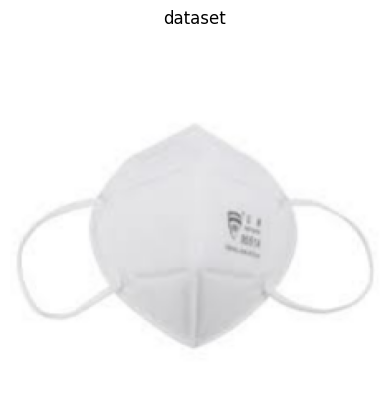

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
  plt.imshow(images[0].numpy().astype("uint8"))
  plt.title(class_names[labels[0]])
  plt.axis("off")

In [ ]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42


#Ddefine DATA_DIR el path de kagglehub download
DATA_DIR = os.path.join(dataset_path, 'dataset')


train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'Training'),
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'Testing'),
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print("Clases detectadas", class_names)

Found 2508 files belonging to 6 classes.
Found 464 files belonging to 6 classes.
Clases detectadas ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


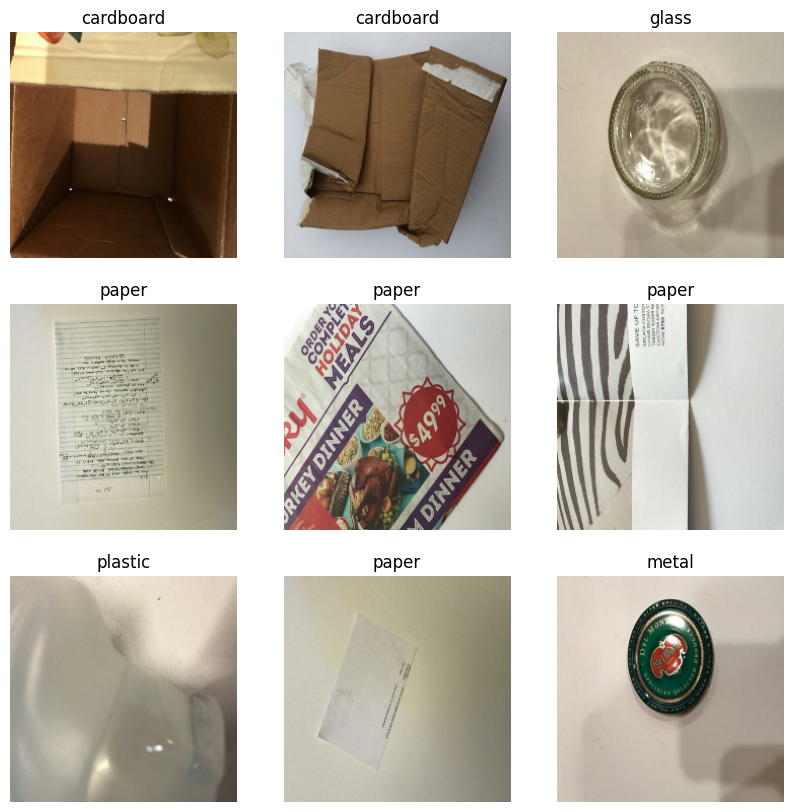

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Este fragmento de codigo prepara los conjuntos de datos de entrenamiento (train_ds) y validacion (val_ds) para ser utilizados en un modeo MobileNetV2 en TensorFlow. Primero, AUTOTUNE = TF.data.AUTOTUNE permite que TensorFlow optimice automaticamente el uso de recursos al cargar los datos.Luego, preprocess_input aplica el preprocesamiento especiico de MobileNetV2, transformando los valores de los pixeles de las imagenes al formato esperado por esta red neuronal. Con map(), cada imagen (x) se convierte al tipo float32 mediatne tf.cast() y posteriormente se preprocesa, mientras que las etiquetas (y) permanecen sin cambios. Finalmente prefetch(AUTOTUNE) carga los siguientes lotes de datos en segundo plano mientras el modelo esta entrenando mejorando el rendimiento y reduciendo los tiempos de espera durante el entrenamiento.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y:(preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y:(preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

##Crear un modelo de clsificacion de imagenes basado en MobileNetV2 preentrenada en ImageNet.
* La red base se mantiene congelada para aprovecha sus caracteristicas aprendidas, y se agregan nuevs capas para clasificar las imagenes en las categorias definidas.
* Finalmente el modelo se compila usando el optimizador Adam y la metrica de precision (Accuracy) para su entrenamiento y evaluacion


In [ ]:
#Crear el modelo MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##Entrenar

Para probar rapido usa EPOCHS = 1

In [ ]:
#EarlyStopping detiene el entrenamiento cuando ve que ya no aprende
EPOCHS = 1

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2, #Si con dos EPOCHS consecutivas no aprende el modelo va a parar
        restore_best_weights=True,
    )
]

history = [
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
    )
]

79/79 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5865 - loss: 1.0776 - val_accuracy: 0.7457 - val_loss: 0.7496


In [ ]:
loss, acc = model.evaluate(val_ds, verbose=0)
print(f"Loss: {loss:.2f}")
print(f"Accuracy: {acc*100:.2f}%")

Loss: 0.75
Accuracy: 74.57%
